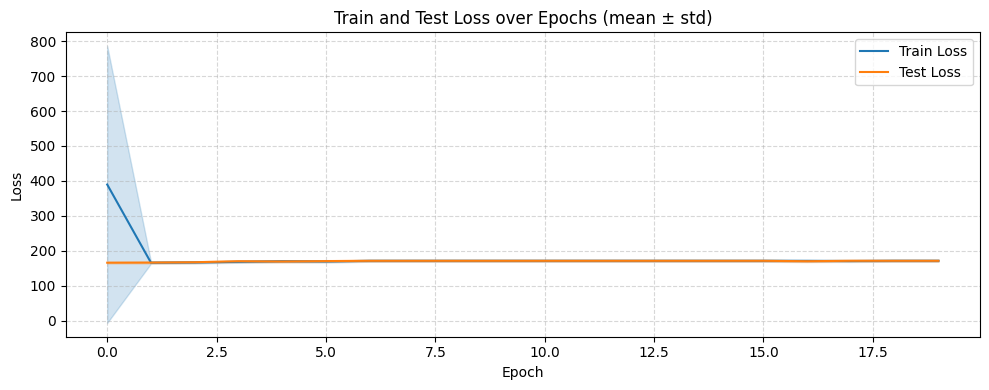

In [2]:
import pickle

import numpy as np
import matplotlib.pyplot as plt

with open("../out/loss_VASAE_KSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl", "rb") as f:
    data = pickle.load(f)
start_id = 0
train_loss_means, train_loss_stds, test_loss_means, test_loss_stds = data["train_loss"][start_id:], data["train_loss_stds"][start_id:], data["test_loss"][start_id:], data["test_loss_stds"][start_id:], 

epochs = np.arange(start_id, start_id + len(train_loss_means))

plt.figure(figsize=(10, 4))

# training curve with std band
plt.plot(epochs, train_loss_means, label="Train Loss", color='tab:blue')
plt.fill_between(
    epochs,
    np.array(train_loss_means) - np.array(train_loss_stds),
    np.array(train_loss_means) + np.array(train_loss_stds),
    color='tab:blue',
    alpha=0.2
)

# test curve with std band
plt.plot(epochs, test_loss_means, label="Test Loss", color='tab:orange')
plt.fill_between(
    epochs,
    np.array(test_loss_means) - np.array(test_loss_stds),
    np.array(test_loss_means) + np.array(test_loss_stds),
    color='tab:orange',
    alpha=0.2
)

plt.title("Train and Test Loss over Epochs (mean ± std)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# final test loss
test_loss_means[-1], test_loss_stds[-1]

(np.float32(0.12670575), np.float32(0.027185949))

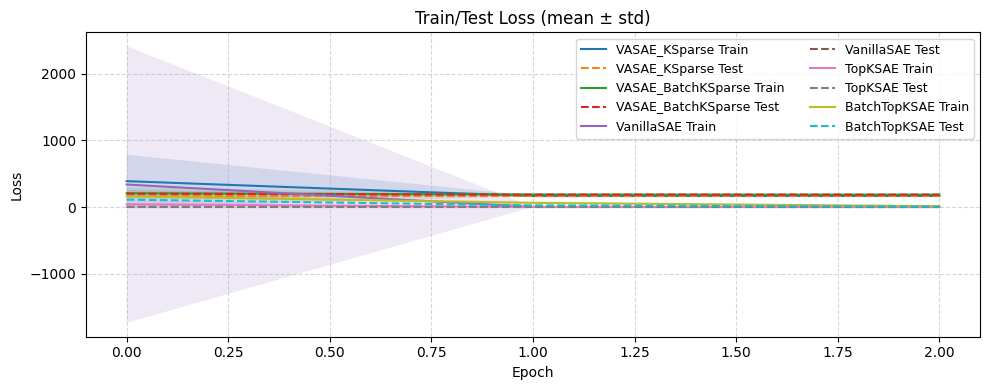

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

start_id = 0

# 不同模型的 pkl 路径和显示名
models = {
    "VASAE_KSparse": "../out/loss_VASAE_KSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VASAE_BatchKSparse": "../out/loss_VASAE_BatchKSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VanillaSAE": "../out/loss_VanillaSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "TopKSAE": "../out/loss_TopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "BatchTopKSAE": "../out/loss_BatchTopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
}

plt.figure(figsize=(10, 4))

for name, path in models.items():
    with open(path, "rb") as f:
        data = pickle.load(f)

    train_mean = data["train_loss"][start_id:3]
    train_std  = data["train_loss_stds"][start_id:3]
    test_mean  = data["test_loss"][start_id:3]
    test_std   = data["test_loss_stds"][start_id:3]

    epochs = np.arange(start_id, start_id + len(train_mean))

    # train
    plt.plot(epochs, train_mean, label=f"{name} Train")
    plt.fill_between(
        epochs,
        np.array(train_mean) - np.array(train_std),
        np.array(train_mean) + np.array(train_std),
        alpha=0.15
    )

    # test
    plt.plot(epochs, test_mean, linestyle="--", label=f"{name} Test")
    plt.fill_between(
        epochs,
        np.array(test_mean) - np.array(test_std),
        np.array(test_mean) + np.array(test_std),
        alpha=0.15
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss (mean ± std)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

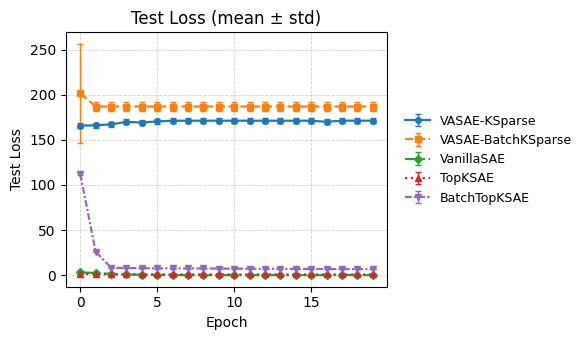

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

start_id = 0

models = {
    "VASAE-KSparse": "../out/loss_VASAE_KSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VASAE-BatchKSparse": "../out/loss_VASAE_BatchKSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VanillaSAE": "../out/loss_VanillaSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "TopKSAE": "../out/loss_TopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "BatchTopKSAE": "../out/loss_BatchTopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
}

# 线型 / marker：黑白可区分
line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v"]

plt.figure(figsize=(6, 3.5))

for i, (name, path) in enumerate(models.items()):
    with open(path, "rb") as f:
        data = pickle.load(f)

    test_mean = np.array(data["test_loss"][start_id:])
    test_std  = np.array(data["test_loss_stds"][start_id:])
    epochs = np.arange(start_id, start_id + len(test_mean))

    plt.errorbar(
        epochs,
        test_mean,
        yerr=test_std,
        linestyle=line_styles[i % len(line_styles)],
        marker=markers[i % len(markers)],
        linewidth=1.6,
        markersize=4,
        capsize=2,
        elinewidth=1.0,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss (mean ± std)")
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

plt.legend(
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

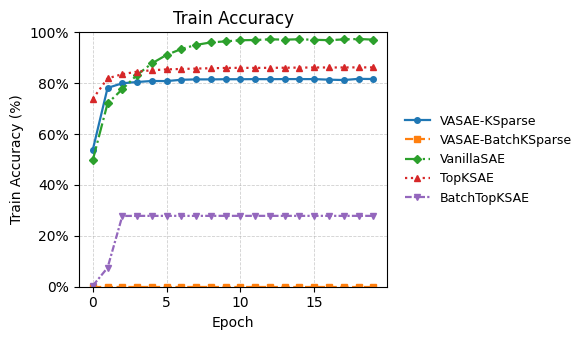

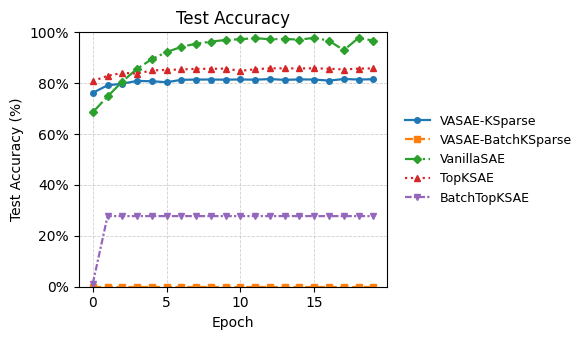

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

start_id = 0

models = {
    "VASAE-KSparse": "../out/loss_VASAE_KSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VASAE-BatchKSparse": "../out/loss_VASAE_BatchKSparse_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "VanillaSAE": "../out/loss_VanillaSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "TopKSAE": "../out/loss_TopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
    "BatchTopKSAE": "../out/loss_BatchTopKSAE_gpt2_transformer_h_5_openwebtext_wocen.pkl",
}

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
markers = ["o", "s", "D", "^", "v"]

# =========================
# Train Accuracy
# =========================
plt.figure(figsize=(6, 3.5))

for i, (name, path) in enumerate(models.items()):
    with open(path, "rb") as f:
        data = pickle.load(f)

    acc = np.array(data["train_acc_epoch"][start_id:])
    epochs = np.arange(start_id, start_id + len(acc))

    plt.plot(
        epochs,
        acc,
        linestyle=line_styles[i % len(line_styles)],
        marker=markers[i % len(markers)],
        linewidth=1.6,
        markersize=4,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy (%)")
plt.title("Train Accuracy")
plt.ylim(0.0, 1.0)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

plt.legend(
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

# =========================
# Test Accuracy
# =========================
plt.figure(figsize=(6, 3.5))

for i, (name, path) in enumerate(models.items()):
    with open(path, "rb") as f:
        data = pickle.load(f)

    acc = np.array(data["test_acc_epoch"][start_id:])
    epochs = np.arange(start_id, start_id + len(acc))

    plt.plot(
        epochs,
        acc,
        linestyle=line_styles[i % len(line_styles)],
        marker=markers[i % len(markers)],
        linewidth=1.6,
        markersize=4,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy")
plt.ylim(0.0, 1.0)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

plt.legend(
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()